
# YOLOv8 & YOLO12 Detection Notebook (Ultralytics API)

Train, validate, and visualize YOLOv8/YOLO12 detectors on the AOI dataset using the Ultralytics Python API. Dataset preparation stays minimal (no manual augmentation copies) and all augmentation knobs are handled directly through Ultralytics, including optional Albumentations hooks.



**Workflow**

1. Extract the YOLO-formatted AOI dataset under `data/detection/` if required.
2. Restructure the splits into `data/detection/aoi_augmented/{train,val,test}/(images|labels)`.
3. Preview a random training sample for sanity.
4. Install Ultralytics + Albumentations, define optional custom transforms.
5. Train/validate YOLOv8 via the Python API (no CLI).
6. Train YOLO12 twice: one run with custom Albumentations, another with augmentations disabled for comparison.
7. Use `YOLO.val()` / `YOLO.predict()` for evaluation and qualitative inspection.


In [1]:

from __future__ import annotations

import random
import shutil
import zipfile
from pathlib import Path
from typing import Dict, List, Sequence

import cv2
import yaml

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "helpers").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DETECTION_DIR = PROJECT_ROOT / "data" / "detection"
SOURCE_DATASET_YAML = DETECTION_DIR / "aoi.yaml"
PREPARED_DATASET_ROOT = DETECTION_DIR / "aoi_augmented"
PREPARED_DATASET_YAML = DETECTION_DIR / "aoi_augmented.yaml"
YOLO_IMAGE_SIZE = 640
RNG_SEED = 1337

print(f"Project root       : {PROJECT_ROOT}")
print(f"Detection yaml     : {SOURCE_DATASET_YAML}")
print(f"Prepared dataset   : {PREPARED_DATASET_ROOT}")


Project root       : /home/jwwang/workspace/github/deep-learning-pj
Detection yaml     : /home/jwwang/workspace/github/deep-learning-pj/data/detection/aoi.yaml
Prepared dataset   : /home/jwwang/workspace/github/deep-learning-pj/data/detection/aoi_augmented


### Ensure the detection dataset is extracted

In [2]:

def ensure_detection_dataset_ready(dataset_yaml: Path, archives: Sequence[Path]) -> Path:
    '''Extract archives into the yaml's base path if expected folders are missing.'''
    if not dataset_yaml.exists():
        raise FileNotFoundError(f"Missing dataset yaml at {dataset_yaml}")
    base_dir = dataset_yaml.parent
    with dataset_yaml.open("r", encoding="utf-8") as fp:
        data_cfg = yaml.safe_load(fp)
    data_path = data_cfg.get("path")
    if data_path:
        base_path = Path(data_path)
        if not base_path.is_absolute():
            base_path = (base_dir / base_path).resolve()
    else:
        base_path = base_dir
    expected_dirs = ["aoi-1", "aoi-2", "aoi-3"]
    if all((base_path / d).exists() for d in expected_dirs):
        print("Detection dataset already extracted.")
        return base_path
    extracted = False
    for archive in archives:
        if not archive.exists():
            continue
        print(f"Extracting {archive.name} -> {base_path}")
        with zipfile.ZipFile(archive) as zf:
            zf.extractall(base_path)
        extracted = True
    if not extracted:
        raise RuntimeError("No detection archives found to extract.")
    return base_path


DATASET_BASE_PATH = ensure_detection_dataset_ready(
    SOURCE_DATASET_YAML,
    [
        DETECTION_DIR / "aoi.zip",
        DETECTION_DIR / "aoi-train.zip",
        DETECTION_DIR / "aoi-val.zip",
    ],
)
print("Dataset base path:", DATASET_BASE_PATH)


Detection dataset already extracted.
Dataset base path: /home/jwwang/workspace/github/deep-learning-pj/data/data


### Restructure the dataset (no manual augmentation)

In [3]:

IMG_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp")


def _normalize_names(names_cfg: Dict | List) -> List[str]:
    if isinstance(names_cfg, dict):
        return [names_cfg[k] for k in sorted(names_cfg.keys())]
    return list(names_cfg)


def _dataset_root(dataset_yaml: Path, data_path: str | None) -> Path:
    if data_path:
        base = Path(data_path)
        if not base.is_absolute():
            base = (dataset_yaml.parent / base).resolve()
    else:
        base = dataset_yaml.parent
    return base


def _expand_split_entry(entry: str | Path, dataset_root: Path) -> List[Path]:
    entry_path = Path(entry)
    if not entry_path.is_absolute():
        entry_path = (dataset_root / entry_path).resolve()
    if entry_path.is_dir():
        return sorted([p for p in entry_path.rglob("*") if p.suffix.lower() in IMG_EXTENSIONS])
    if entry_path.suffix.lower() == ".txt" and entry_path.exists():
        result = []
        for line in entry_path.read_text().splitlines():
            candidate = line.strip()
            if not candidate:
                continue
            path = Path(candidate)
            if not path.is_absolute():
                path = (entry_path.parent / path).resolve()
            if path.exists() and path.suffix.lower() in IMG_EXTENSIONS:
                result.append(path)
        return sorted(result)
    if entry_path.exists() and entry_path.suffix.lower() in IMG_EXTENSIONS:
        return [entry_path]
    return []


def _label_path_for_image(image_path: Path, dataset_root: Path) -> Path:
    rel = image_path.relative_to(dataset_root)
    parts = list(rel.parts)
    if "images" not in parts:
        raise ValueError(f"Could not locate 'images' directory in {image_path}")
    idx = parts.index("images")
    parts[idx] = "labels"
    return (dataset_root / Path(*parts)).with_suffix(".txt")


def _flattened_name(path: Path) -> str:
    if len(path.parents) > 1:
        group = path.parents[1].name
    else:
        group = path.parent.name
    group = group.replace(" ", "_")
    stem = path.stem.replace(" ", "_")
    return f"{group}_{stem}" if group else stem


def prepare_detection_dataset(dataset_yaml: Path, output_root: Path) -> Path:
    data_cfg = yaml.safe_load(dataset_yaml.read_text())
    class_names = _normalize_names(data_cfg.get("names", {}))
    dataset_root = _dataset_root(dataset_yaml, data_cfg.get("path"))

    splits: Dict[str, List[Path]] = {}
    for split_name in ("train", "val", "test"):
        entries = data_cfg.get(split_name)
        if entries is None:
            continue
        if not isinstance(entries, (list, tuple)):
            entries = [entries]
        paths: List[Path] = []
        for entry in entries:
            paths.extend(_expand_split_entry(entry, dataset_root))
        splits[split_name] = sorted(paths)

    if output_root.exists():
        shutil.rmtree(output_root)
    for split in ("train", "val", "test"):
        (output_root / split / "images").mkdir(parents=True, exist_ok=True)
        (output_root / split / "labels").mkdir(parents=True, exist_ok=True)

    random.seed(RNG_SEED)
    stats = {"train": 0, "val": 0, "test": 0}

    for split, items in splits.items():
        if not items:
            continue
        split_img_root = output_root / split / "images"
        split_lbl_root = output_root / split / "labels"
        for img_path in items:
            label_path = _label_path_for_image(img_path, dataset_root)
            base_name = _flattened_name(img_path)
            dest_img = split_img_root / f"{base_name}{img_path.suffix.lower()}"
            dest_lbl = split_lbl_root / f"{base_name}.txt"
            shutil.copy2(img_path, dest_img)
            if label_path.exists():
                shutil.copy2(label_path, dest_lbl)
            else:
                dest_lbl.write_text("", encoding="utf-8")
            stats[split] += 1

    data_yaml = {
        "path": str(output_root.resolve()),
        "train": "train/images",
        "val": "val/images",
        "test": "test/images",
        "nc": len(class_names),
        "names": {idx: name for idx, name in enumerate(class_names)},
    }
    PREPARED_DATASET_YAML.write_text(yaml.safe_dump(data_yaml, sort_keys=False), encoding="utf-8")
    print("Wrote:", PREPARED_DATASET_YAML)
    print("Split counts:", stats)
    return PREPARED_DATASET_YAML


PREPARED_DATASET_YAML_PATH = prepare_detection_dataset(
    SOURCE_DATASET_YAML,
    PREPARED_DATASET_ROOT,
)


Wrote: /home/jwwang/workspace/github/deep-learning-pj/data/detection/aoi_augmented.yaml
Split counts: {'train': 200, 'val': 156, 'test': 173}


### Visual sanity check

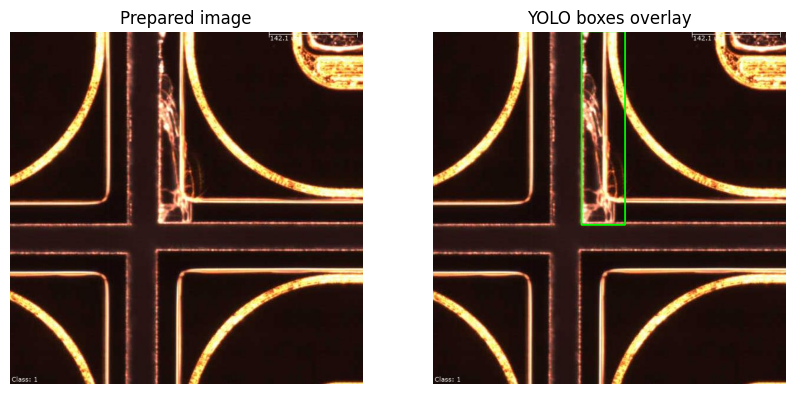

In [4]:

import matplotlib.pyplot as plt

train_image_dir = PREPARED_DATASET_ROOT / "train" / "images"
train_label_dir = PREPARED_DATASET_ROOT / "train" / "labels"
sample_image = next(train_image_dir.glob("*.jpg"), None)
if sample_image is None:
    sample_image = next(train_image_dir.glob("*.png"), None)
if sample_image is None:
    raise RuntimeError("No training images found in prepared dataset")
rel_name = sample_image.stem
sample_label = train_label_dir / f"{rel_name}.txt"

img = cv2.cvtColor(cv2.imread(str(sample_image)), cv2.COLOR_BGR2RGB)
display_img = img.copy()
if sample_label.exists():
    h_img, w_img = img.shape[:2]
    for line in sample_label.read_text().splitlines():
        parts = [float(x) for x in line.split()]
        if len(parts) < 5:
            continue
        cls = int(parts[0])
        x_c, y_c, w, h = parts[1:5]
        bw = w * w_img
        bh = h * h_img
        cx = x_c * w_img
        cy = y_c * h_img
        x1 = int(cx - bw / 2)
        y1 = int(cy - bh / 2)
        x2 = int(cx + bw / 2)
        y2 = int(cy + bh / 2)
        color = (0, 255, 0)
        cv2.rectangle(display_img, (x1, y1), (x2, y2), color, 2)
        cv2.putText(display_img, str(cls), (x1, max(0, y1 - 5)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1, cv2.LINE_AA)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.axis("off")
plt.title("Prepared image")
plt.subplot(1, 2, 2)
plt.imshow(display_img)
plt.axis("off")
plt.title("YOLO boxes overlay")
plt.show()


### Install/upgrade Ultralytics + Albumentations

In [5]:

import subprocess
import sys

subprocess.run([
    sys.executable,
    "-m",
    "pip",
    "install",
    "--upgrade",
    "ultralytics",
    "albumentations",
    "opencv-python",
], check=True)


CompletedProcess(args=['/home/jwwang/.conda/envs/sichain-aoi/bin/python', '-m', 'pip', 'install', '--upgrade', 'ultralytics', 'albumentations', 'opencv-python'], returncode=0)

### Define optional custom Albumentations transforms

In [6]:

import albumentations as A

custom_transforms = [
    A.Blur(blur_limit=7, p=0.35),
    A.CLAHE(clip_limit=4.0, p=0.35),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
]
custom_transforms


[Blur(p=0.35, blur_limit=(3, 7)),
 CLAHE(p=0.35, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8)),
 RandomBrightnessContrast(p=0.5, brightness_by_max=True, brightness_limit=(-0.2, 0.2), contrast_limit=(-0.2, 0.2), ensure_safe_range=False)]

## YOLOv8 training via Ultralytics API

In [7]:

from ultralytics import YOLO

# Load YOLOv8 weights (swap for yolov8n/s/l as needed)
y8_model = YOLO("yolov8m.pt")
y8_results = y8_model.train(
    data=str(PREPARED_DATASET_YAML_PATH),
    imgsz=YOLO_IMAGE_SIZE,
    epochs=150,
    batch=16,
    device=0,
    hsv_h=0.03,
    hsv_s=0.6,
    hsv_v=0.5,
    mosaic=1.0,
    translate=0.08,
    scale=0.4,
    fliplr=0.5,
    auto_augment="randaugment",
    project=str(PROJECT_ROOT / "runs_yolov8_det"),
    name="yolov8m-ultra",
)


Ultralytics 8.3.237 🚀 Python-3.10.19 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4090, 24210MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/jwwang/workspace/github/deep-learning-pj/data/detection/aoi_augmented.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.03, hsv_s=0.6, hsv_v=0.5, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8m-ultra, nbs=64, nms=False, opset=None, optimize=False, optimizer=au

### Validate + predict with YOLOv8

In [8]:

y8_val_metrics = y8_model.val(data=str(PREPARED_DATASET_YAML_PATH), imgsz=YOLO_IMAGE_SIZE, split="val")
print("YOLOv8 val metrics:", y8_val_metrics)

y8_predictions = y8_model.predict(
    source=str(PREPARED_DATASET_ROOT / "test" / "images"),
    imgsz=YOLO_IMAGE_SIZE,
    conf=0.25,
    project=str(PROJECT_ROOT / "runs_yolov8_det"),
    name="yolov8m-demo",
    save=True,
)
print("YOLOv8 predictions saved to:", y8_predictions[0].save_dir if y8_predictions else "n/a")


Ultralytics 8.3.237 🚀 Python-3.10.19 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4090, 24210MiB)
Model summary (fused): 92 layers, 25,842,655 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 905.8±447.2 MB/s, size: 68.4 KB)
val: Scanning /home/jwwang/workspace/github/deep-learning-pj/data/detection/aoi_augmented/val/labels.cache... 156 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 156/156 314.0Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 5.0it/s 2.0s.1s
                   all        156        167       0.69      0.579      0.594      0.304
            Acceptable         50         50      0.642       0.56      0.595      0.434
              Ink spot         28         33      0.702      0.515      0.545      0.314
             Edge chip         50         56      0.769      0.786      0.807      0.367
                 Stain         28         28      0.645      

## YOLO12 training with custom Albumentations

In [9]:

y12_model = YOLO("yolo12n.pt")
y12_results = y12_model.train(
    data=str(PREPARED_DATASET_YAML_PATH),
    imgsz=YOLO_IMAGE_SIZE,
    epochs=120,
    batch=16,
    device=0,
    augmentations=custom_transforms,
    mosaic=0.8,
    mixup=0.1,
    erasing=0.4,
    project=str(PROJECT_ROOT / "runs_yolo12_det"),
    name="yolo12n-custom-augs",
)


Ultralytics 8.3.237 🚀 Python-3.10.19 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4090, 24210MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, augmentations=[Blur(p=0.35, blur_limit=(3, 7)), CLAHE(p=0.35, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8)), RandomBrightnessContrast(p=0.5, brightness_by_max=True, brightness_limit=(-0.2, 0.2), contrast_limit=(-0.2, 0.2), ensure_safe_range=False)], auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/jwwang/workspace/github/deep-learning-pj/data/detection/aoi_augmented.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=120, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, ker

### YOLO12 run without augmentations (optional)

In [10]:

y12_noaug = YOLO("yolo12n.pt")
y12_noaug_results = y12_noaug.train(
    data=str(PREPARED_DATASET_YAML_PATH),
    imgsz=YOLO_IMAGE_SIZE,
    epochs=80,
    batch=16,
    device=0,
    hsv_h=0.0,
    hsv_s=0.0,
    hsv_v=0.0,
    translate=0.0,
    scale=0.0,
    fliplr=0.0,
    mosaic=0.0,
    mixup=0.0,
    erasing=0.0,
    auto_augment=None,
    augmentations=None,
    project=str(PROJECT_ROOT / "runs_yolo12_det"),
    name="yolo12n-noaug",
)


Ultralytics 8.3.237 🚀 Python-3.10.19 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4090, 24210MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, augmentations=None, auto_augment=None, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/jwwang/workspace/github/deep-learning-pj/data/detection/aoi_augmented.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=80, erasing=0.0, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n.pt, momentum=0.937, mosaic=0.0, multi_scale=False, name=yolo12n-noaug, nbs=64, nms=False, opset=None, optimize=False, o

### Validate + predict with YOLO12

In [11]:

y12_metrics = y12_model.val(data=str(PREPARED_DATASET_YAML_PATH), imgsz=YOLO_IMAGE_SIZE, split="val")
print("YOLO12 val metrics:", y12_metrics)

y12_predictions = y12_model.predict(
    source=str(PREPARED_DATASET_ROOT / "test" / "images"),
    imgsz=YOLO_IMAGE_SIZE,
    conf=0.25,
    project=str(PROJECT_ROOT / "runs_yolo12_det"),
    name="yolo12-demo",
    save=True,
)
print("YOLO12 predictions saved to:", y12_predictions[0].save_dir if y12_predictions else "n/a")


Ultralytics 8.3.237 🚀 Python-3.10.19 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4090, 24210MiB)
YOLOv12n summary (fused): 159 layers, 2,557,703 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1645.6±453.2 MB/s, size: 68.8 KB)
val: Scanning /home/jwwang/workspace/github/deep-learning-pj/data/detection/aoi_augmented/val/labels.cache... 156 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 156/156 179.9Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 6.2it/s 1.6s.1s
                   all        156        167      0.658      0.569      0.597      0.313
            Acceptable         50         50      0.581       0.62      0.603      0.422
              Ink spot         28         33      0.615      0.582      0.598      0.349
             Edge chip         50         56      0.819      0.645      0.715      0.378
                 Stain         28         28      0.616   